In [7]:
# import library dasar
import numpy as np
import pandas as pd

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # untuk 3D plot
# Agar plot tampil rapi
plt.rcParams['figure.figsize'] = (8, 6)

In [8]:
df = pd.read_csv("../data/data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [10]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [11]:
# Cek data duplikat
df.duplicated().sum()

np.int64(0)

In [12]:
# Distribusi kelas target
print("Nama kelas: ['Benign (B)', 'Malignant (M)']")
df['diagnosis'].value_counts()

Nama kelas: ['Benign (B)', 'Malignant (M)']


diagnosis
B    357
M    212
Name: count, dtype: int64

In [13]:
# Fitur dan label
X = df.drop(columns=['diagnosis']).values
y = df['diagnosis'].values

print("Shape X:", X.shape)
print("Shape y:", y.shape)


Shape X: (569, 32)
Shape y: (569,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardisasi (mean = 0, std = 1)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # fit + transform pada data train
X_test_scaled  = scaler.transform(X_test)       # hanya transform pada data test

X_train_scaled[:5]

C:\Users\MyBook Hype AMD\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\extmath.py:1144: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
C:\Users\MyBook Hype AMD\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\extmath.py:1149: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
C:\Users\MyBook Hype AMD\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\extmath.py:1169: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


array([[-0.23712699, -1.44075296, -0.43531947, -1.36208497, -1.1391179 ,
         0.78057331,  0.71892128,  2.82313451, -0.11914956,  1.09266219,
         2.45817261, -0.26380039, -0.01605246, -0.47041357, -0.47476088,
         0.83836493,  3.25102691,  8.43893667,  3.39198733,  2.62116574,
         2.06120787, -1.23286131, -0.47630949, -1.24792009, -0.97396758,
         0.72289445,  1.18673232,  4.67282796,  0.9320124 ,  2.09724217,
         1.88645014,         nan],
       [-0.23702031,  1.97409619,  1.73302577,  2.09167167,  1.85197292,
         1.319843  ,  3.42627493,  2.01311199,  2.66503199,  2.1270036 ,
         1.55839569,  0.80531919, -0.81268678,  0.75195659,  0.87716951,
        -0.89605315,  1.18122247,  0.18362761,  0.60059598, -0.31771686,
         0.52963649,  2.17331385,  1.3112795 ,  2.08161691,  2.1374055 ,
         0.76192793,  3.26560084,  1.92862053,  2.6989469 ,  1.89116053,
         2.49783848,         nan],
       [-0.23712907, -1.39998202, -1.24962228, -1.3452

In [15]:
# Model SVM tanpa PCA
svm_no_pca = SVC(kernel='rbf', gamma='scale', random_state=42)

# Filter out the NaN column (last column) from X_train_scaled and X_test_scaled
# This assumes the 'Unnamed: 32' column was the last one and contains all NaNs.
X_train_scaled_filtered = X_train_scaled[:, :-1]
X_test_scaled_filtered = X_test_scaled[:, :-1]

svm_no_pca.fit(X_train_scaled_filtered, y_train)

# Prediksi dan evaluasi
y_pred_no_pca = svm_no_pca.predict(X_test_scaled_filtered)

acc_no_pca = accuracy_score(y_test, y_pred_no_pca)
print("Akurasi tanpa PCA:", acc_no_pca)

print("\nClassification Report (tanpa PCA):")
print(classification_report(
    y_test,
    y_pred_no_pca,
    target_names=['Benign', 'Malignant']
))

Akurasi tanpa PCA: 0.9824561403508771

Classification Report (tanpa PCA):
              precision    recall  f1-score   support

      Benign       0.97      1.00      0.99        71
   Malignant       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [16]:
# PCA dengan 3 komponen utama
pca = PCA(n_components=3)

# Filter out the NaN column (last column) from X_train_scaled and X_test_scaled
# This assumes the 'Unnamed: 32' column was the last one and contains all NaNs.
X_train_scaled_filtered = X_train_scaled[:, :-1]
X_test_scaled_filtered = X_test_scaled[:, :-1]

X_train_pca = pca.fit_transform(X_train_scaled_filtered)
X_test_pca  = pca.transform(X_test_scaled_filtered)

print("Shape X_train_pca:", X_train_pca.shape)   # (n_train, 3)
print("Shape X_test_pca:", X_test_pca.shape)     # (n_test, 3)

Shape X_train_pca: (455, 3)
Shape X_test_pca: (114, 3)


In [17]:
# Variansi yg dijelaskan oleh tiap komponen
explained_var = pca.explained_variance_ratio_
print("Explained Variance Ratio Tiap Kompponen:", explained_var)
print("Total Variansi yg dijelaskan 3 komponen pertama:", explained_var.sum())

Explained Variance Ratio Tiap Kompponen: [0.42132688 0.18887304 0.09556973]
Total Variansi yg dijelaskan 3 komponen pertama: 0.7057696576239373


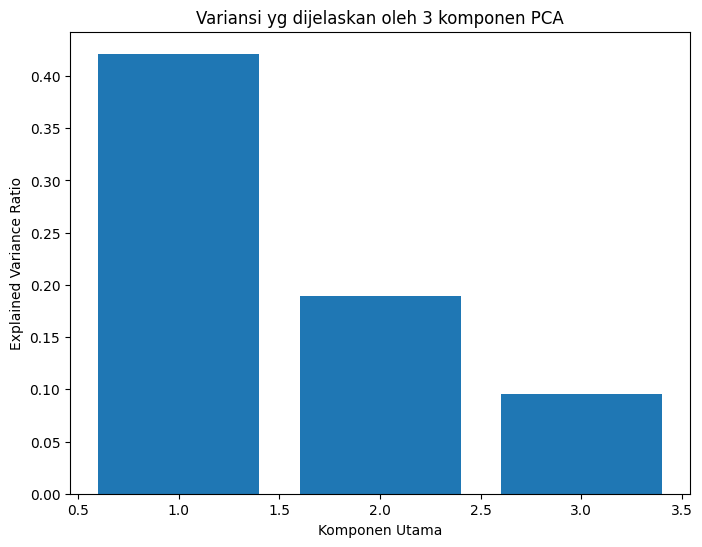

In [18]:
plt.bar([1, 2, 3], explained_var)
plt.xlabel('Komponen Utama')
plt.ylabel('Explained Variance Ratio')
plt.title('Variansi yg dijelaskan oleh 3 komponen PCA')
plt.show()

In [19]:
# Model SVM dengan PCA
svm_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_pca.fit(X_train_pca, y_train)

# Prediksi dan Evaluasi
y_pred_pca = svm_pca.predict(X_test_pca)

acc_pca = accuracy_score(y_test, y_pred_pca)
print("Akurasi SVM dengan PCA (3 komponen):", acc_pca)

print("\nClassification Report (dengan PCA):")
print(classification_report(
    y_test,
    y_pred_pca,
    target_names=['Benign', 'Malignant']
))


Akurasi SVM dengan PCA (3 komponen): 0.956140350877193

Classification Report (dengan PCA):
              precision    recall  f1-score   support

      Benign       0.96      0.97      0.97        71
   Malignant       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



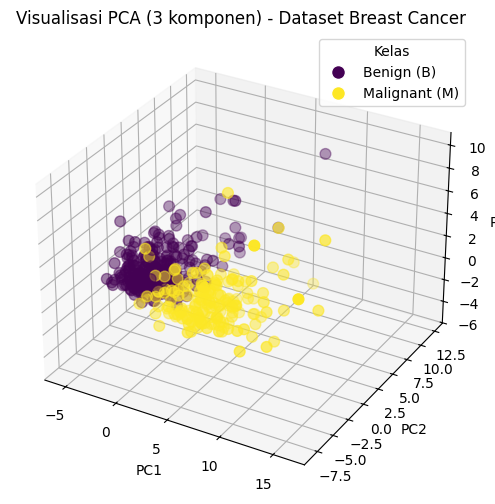

In [20]:
import numpy as np
# Visualisasi 3D PCA (menggunakan data train)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Mengonversi label 'B' dan 'M' ke nilai numerik untuk pewarnaan
y_train_numeric = np.where(y_train == 'M', 1, 0)

scatter = ax.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    X_train_pca[:, 2],
    c=y_train_numeric, # Menggunakan nilai numerik untuk warna
    cmap='viridis', # Menentukan colormap untuk visualisasi
    s=60
)

ax.set_title('Visualisasi PCA (3 komponen) - Dataset Breast Cancer')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

# Tambahkan legend berdasarkan kelas
# Membuat objek legend secara manual karena scatter.legend_elements() tidak mendukung string setelah konversi numerik
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label='Benign (B)',
                          markerfacecolor=scatter.cmap(0.), markersize=10),
                   plt.Line2D([0], [0], marker='o', color='w', label='Malignant (M)',
                          markerfacecolor=scatter.cmap(1.), markersize=10)]

ax.legend(handles=legend_elements, title="Kelas")

plt.show()

In [21]:
# Membandingkan hasil model tanpa dan dengan PCA
comparison = pd.DataFrame({
    'Model': ['SVM tanpa PCA', 'SVM dengan PCA (3 komponen)'],
    'Jumlah Fitur': [X_train_scaled.shape[1], X_train_pca.shape[1]],
    'Akurasi': [acc_no_pca, acc_pca],
    'Variansi Total PCA': ['-', explained_var.sum()]
})

comparison


,Model,Jumlah Fitur,Akurasi,Variansi Total PCA
0,SVM tanpa PCA,32,0.982456,-
1,SVM dengan PCA (3 komponen),3,0.956140,0.70577


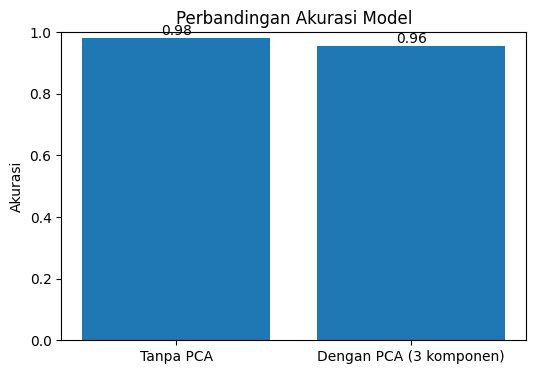

In [22]:
plt.figure(figsize=(6,4))
plt.bar(['Tanpa PCA', 'Dengan PCA (3 komponen)'], [acc_no_pca, acc_pca])
plt.title('Perbandingan Akurasi Model')
plt.ylabel('Akurasi')
plt.ylim(0, 1)

for i, v in enumerate([acc_no_pca, acc_pca]):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center')

plt.show()
